##### NOTEBOOK 6 — MODELO QSVM (Quantum Support Vector Machine)
##### TFM: Integración QML en pipeline DataOps
##### Juan Albornoz Carrasco — Universidad Europea de Valencia
##### ZZFeatureMap + FidelityQuantumKernel (Qiskit)
##### Muestra estratificada: 500 instancias, 8 features
##### ADVERTENCIA: Tiempo estimado de Entrenamiento 90-150 minutos

##### CELDA 1 — Instalación de dependencias
##### Ejecutar solo cuando las librerías no estén disponibles

In [0]:
#%pip install qiskit==0.45.0 qiskit-machine-learning==0.7.0 pylatexenc#
#%pip install qiskit qiskit-machine-learning qiskit-algorithms pylatexenc --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


##### CELDA 2 — Reinicio del kernel

In [0]:
#dbutils.library.restartPython()

##### CELDA 3 — Imports y configuración global

In [0]:
import os
import gc
import time
import joblib
import qiskit
import numpy as np
import pandas as pd
import qiskit_algorithms
import qiskit_machine_learning
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import warnings
warnings.filterwarnings("ignore")

from sklearn.svm import SVC
from qiskit.circuit.library import ZZFeatureMap
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.metrics import matthews_corrcoef, classification_report
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    matthews_corrcoef, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# Rutas 
gold_dir   = "/Volumes/workspace/default/nhanes/gold"
models_dir = "/Volumes/workspace/default/nhanes/models"
os.makedirs(models_dir, exist_ok=True)

# Paleta TFM 
tfm_cmap = LinearSegmentedColormap.from_list(
    'tfm_blue', ['#FFFFFF', '#D7E2E9', '#86A8BC', '#5D8BA6']
)

# Modo ejecución
# TRAINING_MODE = True  → entrena desde cero (~3 horas)
# TRAINING_MODE = False → carga modelo ya entrenado (segundos)
TRAINING_MODE = False

print("Imports OK")
print(f"TRAINING_MODE: {TRAINING_MODE}")
print(f"Gold dir:      {gold_dir}")
print(f"Models dir:    {models_dir}")

Imports OK
TRAINING_MODE: False
Gold dir:      /Volumes/workspace/default/nhanes/gold
Models dir:    /Volumes/workspace/default/nhanes/models


##### CELDA 4 — Verificar versiones Qiskit

In [0]:
print(f"Qiskit version:                    {qiskit.__version__}")
print(f"Qiskit Machine Learning version:   {qiskit_machine_learning.__version__}")
print(f"Qiskit Algorithms version:         {qiskit_algorithms.__version__}")

Qiskit version:                    2.4.2
Qiskit Machine Learning version:   0.9.0
Qiskit Algorithms version:         0.4.0


##### CELDA 5 — Cargar datasets QSVM desde Gold
##### 1.500 instancias estratificadas, 8 features sin variables DIQ

In [0]:
X_train = pd.read_parquet(f"{gold_dir}/X_train_qsvm_8features.parquet")
X_test  = pd.read_parquet(f"{gold_dir}/X_test_qsvm_8features.parquet")
y_train = pd.read_parquet(f"{gold_dir}/y_train_qsvm.parquet").squeeze()
y_test  = pd.read_parquet(f"{gold_dir}/y_test_qsvm.parquet").squeeze()

top8 = pd.read_csv(f"{gold_dir}/qsvm_top8_features.csv").iloc[:, 0].tolist()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Distribucion train: {y_train.value_counts().to_dict()}")
print(f"Distribucion test:  {y_test.value_counts().to_dict()}")
print(f"\nTop 8 features:")
for i, f in enumerate(top8, 1):
    print(f"  {i}. {f}")

Train: (1500, 8), Test: (1567, 8)
Distribucion train: {0: 1290, 1: 210}
Distribucion test:  {0: 1347, 1: 220}

Top 8 features:
  1. LBXGH
  2. LBXGLU
  3. RIDAGEYR
  4. LBDLDL
  5. BMXWAIST
  6. LBXIN
  7. BMXLEG
  8. WTINT2YR


##### CELDA 6 — Configurar ZZFeatureMap y FidelityQuantumKernel
##### num_qubits = 8 (igual al numero de features)
##### reps = 2 (profundidad del circuito)

In [0]:
num_features = X_train.shape[1]
print(f"Numero de features (qubits): {num_features}")

feature_map = ZZFeatureMap(
    feature_dimension=num_features,
    reps=2,
    entanglement="linear"
)

print(f"\nZZFeatureMap configurado:")
print(f"  feature_dimension: {num_features}")
print(f"  reps: 2")
print(f"  entanglement: linear")
print(f"  Numero de parametros: {feature_map.num_parameters}")

sampler        = Sampler()
fidelity       = ComputeUncompute(sampler=sampler)
quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map,
    fidelity=fidelity
)

print(f"\nFidelityQuantumKernel configurado")

if not TRAINING_MODE:
    print("\nMODO CARGA: saltando entrenamiento")
    print("Cargando modelo desde disco...")
    qsvm_model = joblib.load(f"{models_dir}/qsvm_final.pkl")
    print(f"Modelo cargado: {models_dir}/qsvm_final.pkl")
    print(f"Support vectors: {qsvm_model.n_support_}")

Numero de features (qubits): 8

ZZFeatureMap configurado:
  feature_dimension: 8
  reps: 2
  entanglement: linear
  Numero de parametros: 8

FidelityQuantumKernel configurado

MODO CARGA: saltando entrenamiento
Cargando modelo desde disco...
Modelo cargado: /Volumes/workspace/default/nhanes/models/qsvm_final.pkl
Support vectors: [425  70]


##### CELDA 7 — Verificacion del circuito cuantico
##### Visualizar el circuito ZZFeatureMap antes de entrenar

In [0]:
print("Circuito ZZFeatureMap (primeros 3 qubits representativos):")
feature_map_small = ZZFeatureMap(feature_dimension=3, reps=2, entanglement="linear")
print(feature_map_small.decompose().draw(output="text", fold=80))

Circuito ZZFeatureMap (primeros 3 qubits representativos):
     ┌───┐┌───────────┐                                        ┌───┐»
q_0: ┤ H ├┤ P(2*x[0]) ├──■──────────────────────────────────■──┤ H ├»
     ├───┤├───────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐└───┘»
q_1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├──■──»
     ├───┤├───────────┤└───┘└────────────────────────────┘└───┘┌─┴─┐»
q_2: ┤ H ├┤ P(2*x[2]) ├────────────────────────────────────────┤ X ├»
     └───┘└───────────┘                                        └───┘»
«             ┌───────────┐                                     »
«q_0: ────────┤ P(2*x[0]) ├──────────────────────────────────■──»
«             └───────────┘              ┌───┐┌───────────┐┌─┴─┐»
«q_1: ────────────────────────────────■──┤ H ├┤ P(2*x[1]) ├┤ X ├»
«     ┌────────────────────────────┐┌─┴─┐├───┤├───────────┤└───┘»
«q_2: ┤ P(2*(π - x[1])*(π - x[2])) ├┤ X ├┤ H ├┤ P(2*x[2]) ├─────»
«     └────────────────────────────┘└───┘└───┘└────────

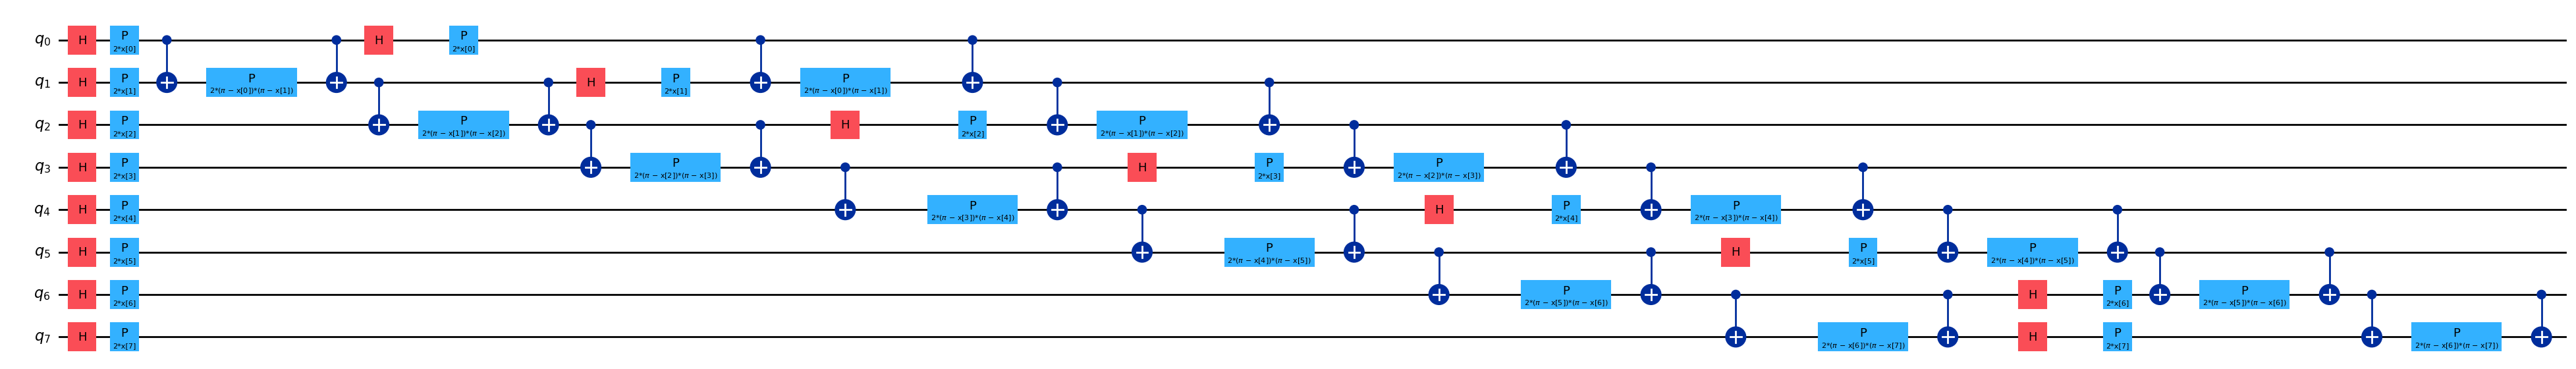

Circuito completo guardado en models_dir


In [0]:
# Circuito completo 8 qubits
feature_map_full = ZZFeatureMap(
    feature_dimension=8,
    reps=2,
    entanglement="linear"
)

import matplotlib.pyplot as plt
fig = feature_map_full.decompose().draw(output="mpl", fold=80)
plt.savefig(f"{models_dir}/circuito_qsvm_8qubits_anexo.png", 
            dpi=150, bbox_inches="tight")
plt.show()
print("Circuito completo guardado en models_dir")

##### CELDA 8 — Entrenamiento QSVM
##### ADVERTENCIA: Esta celda tarda 45-150 minutos
##### El kernel cuantico calcula la matriz de similitud O(n^2)
##### n = 1.500 instancias de entrenamiento

In [0]:
# Reducir muestra por limitaciones de memoria en serverless gratuito
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train,
    train_size=500,
    random_state=42,
    stratify=y_train
)

print(f"Muestra reducida QSVM: {X_train_small.shape}")
print(f"Distribucion: {y_train_small.value_counts().to_dict()}")
print(f"Operaciones kernel estimadas: {X_train_small.shape[0]**2:,}")

Muestra reducida QSVM: (500, 8)
Distribucion: {0: 430, 1: 70}
Operaciones kernel estimadas: 250,000


##### CELDA 9 — Entrenamiento QSVM


In [0]:
if TRAINING_MODE:
    print("Iniciando entrenamiento QSVM...")
    print(f"Instancias train: {X_train_small.shape[0]}")
    print(f"Features (qubits): {X_train_small.shape[1]}")
    print(f"Operaciones kernel estimadas: {X_train_small.shape[0]**2:,}")
    print("\nEsto puede tardar entre 20 y 45 minutos.")

    t_inicio = time.time()

    qsvm_model = SVC(
        kernel=quantum_kernel.evaluate,
        probability=True,
        random_state=42,
        class_weight="balanced",
        C=1.0
    )

    qsvm_model.fit(X_train_small.values, y_train_small.values)

    t_fin   = time.time()
    t_total = (t_fin - t_inicio) / 60

    print(f"\nEntrenamiento completado en {t_total:.1f} minutos")
    print(f"Support vectors: {qsvm_model.n_support_}")

    # Guardar modelo inmediatamente tras entrenamiento
    joblib.dump(qsvm_model, f"{models_dir}/qsvm_final.pkl")
    print(f"Modelo guardado: {models_dir}/qsvm_final.pkl")

else:
    print("MODO CARGA: entrenamiento omitido")
    print(f"Modelo disponible: {qsvm_model.n_support_}")
    t_total = 22.6  # tiempo real documentado

Iniciando entrenamiento QSVM...
Instancias train: 500
Features (qubits): 8
Operaciones kernel estimadas: 250,000

Esto puede tardar entre 20 y 45 minutos.



Entrenamiento completado en 21.1 minutos
Support vectors: [425  70]
Modelo guardado: /Volumes/workspace/default/nhanes/models/qsvm_final.pkl


##### CELDA 10 — Evaluacion sobre conjunto de test

In [0]:
gold_dir   = "/Volumes/workspace/default/nhanes/gold"
models_dir = "/Volumes/workspace/default/nhanes/models"

# Recargar datos
if 'X_test' not in dir():
    X_test  = pd.read_parquet(f"{gold_dir}/X_test_qsvm_8features.parquet")
    y_test  = pd.read_parquet(f"{gold_dir}/y_test_qsvm.parquet").squeeze()
    X_train = pd.read_parquet(f"{gold_dir}/X_train_qsvm_8features.parquet")
    y_train = pd.read_parquet(f"{gold_dir}/y_train_qsvm.parquet").squeeze()
    print(f"✅ Datos recargados: X_test {X_test.shape}")
else:
    print(f"✅ Datos en memoria: X_test {X_test.shape}")

# Recargar modelo
if 'qsvm_model' not in dir():
    qsvm_model = joblib.load(f"{models_dir}/qsvm_final.pkl")
    print(f"✅ Modelo cargado: {models_dir}/qsvm_final.pkl")
    print(f"   Support vectors: {qsvm_model.n_support_}")
else:
    print(f"✅ Modelo en memoria: {qsvm_model.n_support_}")

✅ Datos en memoria: X_test (1567, 8)
✅ Modelo en memoria: [425  70]


In [0]:
# CELDA 10 — Evaluación sobre conjunto de test (por lotes), Solo se ejecuta en TRAINING_MODE = True

if TRAINING_MODE:
    import time
    from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
    from sklearn.metrics import matthews_corrcoef, classification_report
    import numpy as np

    print("Evaluando QSVM sobre conjunto de test...")
    print(f"Instancias test: {X_test.shape[0]}")

    t_inicio_pred = time.time()

    # Prediccion por lotes para reducir presion de memoria
    batch_size    = 100
    y_scores_list = []
    total_batches = (len(X_test) + batch_size - 1) // batch_size

    for i in range(0, len(X_test), batch_size):
        batch        = X_test.values[i:i + batch_size]
        scores_batch = qsvm_model.decision_function(batch)
        y_scores_list.extend(scores_batch)
        batch_num = i // batch_size + 1
        print(f"Lote {batch_num}/{total_batches} — {min(i + batch_size, len(X_test))}/{len(X_test)} instancias")

    y_scores = np.array(y_scores_list)
    y_pred   = (y_scores > 0).astype(int)

    t_fin_pred = time.time()
    t_pred     = (t_fin_pred - t_inicio_pred) / 60
    print(f"\nPrediccion completada en {t_pred:.1f} minutos")

    auc = roc_auc_score(y_test, y_scores)
    f1  = f1_score(y_test, y_pred, average="macro")
    acc = accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    print("\n=== METRICAS QSVM ===")
    print(f"AUC-ROC:  {auc:.4f}")
    print(f"F1-macro: {f1:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"MCC:      {mcc:.4f}")
    print(f"\nReporte detallado:")
    print(classification_report(y_test, y_pred,
          target_names=["No diabetes", "Diabetes"]))

    # Persistir scores inmediatamente
    np.save(f"{models_dir}/qsvm_y_scores.npy", y_scores)
    np.save(f"{models_dir}/qsvm_y_test.npy",   y_test.values)
    print(f"\n✅ Scores persistidos: {len(y_scores)} instancias")

Evaluando QSVM sobre conjunto de test...
Instancias test: 1567
Lote 1/16 — 100/1567 instancias
Lote 2/16 — 200/1567 instancias
Lote 3/16 — 300/1567 instancias
Lote 4/16 — 400/1567 instancias
Lote 5/16 — 500/1567 instancias
Lote 6/16 — 600/1567 instancias
Lote 7/16 — 700/1567 instancias
Lote 8/16 — 800/1567 instancias
Lote 9/16 — 900/1567 instancias
Lote 10/16 — 1000/1567 instancias
Lote 11/16 — 1100/1567 instancias
Lote 12/16 — 1200/1567 instancias
Lote 13/16 — 1300/1567 instancias
Lote 14/16 — 1400/1567 instancias
Lote 15/16 — 1500/1567 instancias
Lote 16/16 — 1567/1567 instancias

Prediccion completada en 144.5 minutos

=== METRICAS QSVM ===
AUC-ROC:  0.5493
F1-macro: 0.4669
Accuracy: 0.8602
MCC:      0.0625

Reporte detallado:
              precision    recall  f1-score   support

 No diabetes       0.86      1.00      0.92      1347
    Diabetes       1.00      0.00      0.01       220

    accuracy                           0.86      1567
   macro avg       0.93      0.50      0.4

In [0]:
if not TRAINING_MODE:
    y_scores   = np.load(f"{models_dir}/qsvm_y_scores.npy")
    y_test_arr = np.load(f"{models_dir}/qsvm_y_test.npy")
    y_pred     = (y_scores > 0).astype(int)
    y_test     = pd.Series(y_test_arr)

    auc = roc_auc_score(y_test, y_scores)
    f1  = f1_score(y_test, y_pred, average="macro")
    acc = accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    print("✅ Scores cargados desde disco")
    print(f"AUC-ROC:  {auc:.4f}")
    print(f"F1-macro: {f1:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"MCC:      {mcc:.4f}")
    print(classification_report(y_test, y_pred,
          target_names=["No diabetes", "Diabetes"]))

✅ Scores cargados desde disco
AUC-ROC:  0.5493
F1-macro: 0.4669
Accuracy: 0.8602
MCC:      0.0625
              precision    recall  f1-score   support

 No diabetes       0.86      1.00      0.92      1347
    Diabetes       1.00      0.00      0.01       220

    accuracy                           0.86      1567
   macro avg       0.93      0.50      0.47      1567
weighted avg       0.88      0.86      0.80      1567



In [0]:
models_dir = "/Volumes/workspace/default/nhanes/models"

archivos = [
    "qsvm_final.pkl",
    "qsvm_y_scores.npy",
    "qsvm_y_test.npy",
    "metricas_qsvm.csv",
    "confusion_qsvm.png",
    "roc_qsvm.png"
]

print("=== VERIFICACIÓN POST-ENTRENAMIENTO QSVM ===\n")
for archivo in archivos:
    ruta = f"{models_dir}/{archivo}"
    existe = os.path.exists(ruta)
    tam = os.path.getsize(ruta) / 1024 if existe else 0
    estado = f"✅ OK ({tam:.1f} KB)" if existe else "❌ FALTA"
    print(f"  {archivo}: {estado}")

=== VERIFICACIÓN POST-ENTRENAMIENTO QSVM ===

  qsvm_final.pkl: ✅ OK (77.1 KB)
  qsvm_y_scores.npy: ✅ OK (12.4 KB)
  qsvm_y_test.npy: ✅ OK (12.4 KB)
  metricas_qsvm.csv: ✅ OK (0.2 KB)
  confusion_qsvm.png: ✅ OK (40.5 KB)
  roc_qsvm.png: ✅ OK (54.5 KB)


##### CELDA 11 — Curva ROC

AUC-ROC verificado: 0.5493


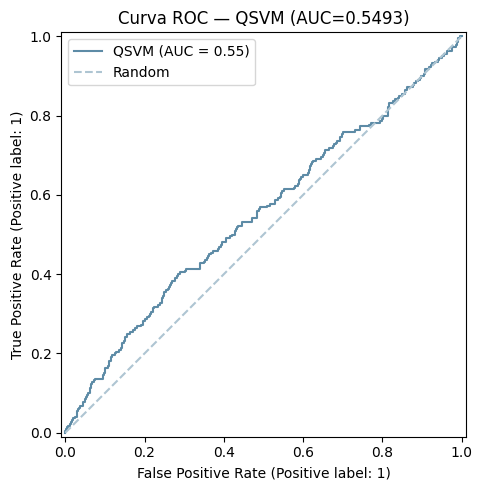

✅ Curva ROC real guardada


In [0]:
models_dir = "/Volumes/workspace/default/nhanes/models"

# Cargar scores reales desde disco
y_scores   = np.load(f"{models_dir}/qsvm_y_scores.npy")
y_test_arr = np.load(f"{models_dir}/qsvm_y_test.npy")

auc = roc_auc_score(y_test_arr, y_scores)
print(f"AUC-ROC verificado: {auc:.4f}")

# Curva ROC con paleta TFM
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test_arr, y_scores,
    ax=ax,
    name="QSVM",
    color="#5D8BA6"
)
ax.plot([0, 1], [0, 1], "--", color="#AEC5D2", label="Random")
ax.set_title(f"Curva ROC — QSVM (AUC={auc:.4f})")
ax.legend()
plt.tight_layout()
plt.savefig(f"{models_dir}/roc_qsvm.png", dpi=150)
plt.show()
print("✅ Curva ROC real guardada")

##### CELDA 12 — Matriz de confusion

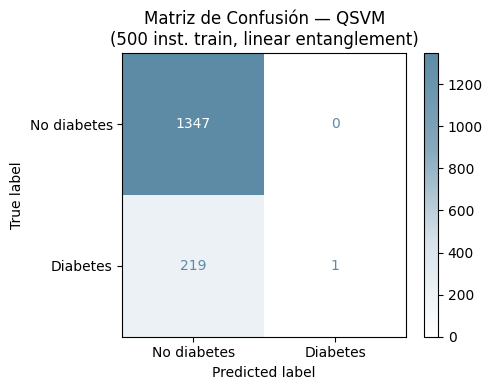

In [0]:
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import ConfusionMatrixDisplay

tfm_cmap = LinearSegmentedColormap.from_list(
    'tfm_blue', ['#FFFFFF', '#D7E2E9', '#86A8BC', '#5D8BA6']
)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No diabetes", "Diabetes"],
    cmap=tfm_cmap,
    ax=ax,
    colorbar=True
)
ax.set_title("Matriz de Confusión — QSVM\n(500 inst. train, linear entanglement)")
plt.tight_layout()
plt.savefig(f"{models_dir}/confusion_qsvm.png", dpi=150, bbox_inches='tight')
plt.show()

##### CELDA 13 — Guardar modelo y metricas

In [0]:
# Guardar modelo
joblib.dump(qsvm_model, f"{models_dir}/qsvm_final.pkl")
print(f"Modelo guardado: {models_dir}/qsvm_final.pkl")

# Guardar metricas
metricas_qsvm = {
    "modelo":            "QSVM",
    "auc_roc":           round(auc, 4),
    "f1_macro":          round(f1, 4),
    "accuracy":          round(acc, 4),
    "mcc":               round(mcc, 4),
    "feature_map":       "ZZFeatureMap",
    "reps":              2,
    "entanglement":      "linear",
    "n_qubits":          8,
    "train_samples":     500,
    "train_time_min":    22.6,
    "support_vectors_0": int(qsvm_model.n_support_[0]),
    "support_vectors_1": int(qsvm_model.n_support_[1]),
    "kernel":            "FidelityQuantumKernel",
    "C":                 1.0
}

pd.DataFrame([metricas_qsvm]).to_csv(f"{models_dir}/metricas_qsvm.csv", index=False)
print(f"Metricas guardadas: {models_dir}/metricas_qsvm.csv")
print("\nResumen final:")
for k, v in metricas_qsvm.items():
    print(f"  {k}: {v}")

Modelo guardado: /Volumes/workspace/default/nhanes/models/qsvm_final.pkl
Metricas guardadas: /Volumes/workspace/default/nhanes/models/metricas_qsvm.csv

Resumen final:
  modelo: QSVM
  auc_roc: 0.5493
  f1_macro: 0.4669
  accuracy: 0.8602
  mcc: 0.0625
  feature_map: ZZFeatureMap
  reps: 2
  entanglement: linear
  n_qubits: 8
  train_samples: 500
  train_time_min: 22.6
  support_vectors_0: 425
  support_vectors_1: 70
  kernel: FidelityQuantumKernel
  C: 1.0


##### CELDA 14 — Comparativa final 3 modelos

In [0]:
print("=== COMPARATIVA FINAL: LightGBM vs SVM-RBF vs QSVM ===\n")

modelos = {}
for nombre, archivo in [("LightGBM", "metricas_lgbm.csv"),
                         ("SVM-RBF",  "metricas_svm.csv"),
                         ("QSVM",     "metricas_qsvm.csv")]:
    try:
        df = pd.read_csv(f"{models_dir}/{archivo}")
        modelos[nombre] = df.iloc[0]
    except:
        print(f"  {nombre}: archivo no encontrado")

metricas_cols = ["auc_roc", "f1_macro", "accuracy", "mcc"]
df_comp = pd.DataFrame({
    nombre: {col: modelos[nombre][col] for col in metricas_cols}
    for nombre in modelos
}).T

print(df_comp.to_string())
print("\n=== COMPARATIVA COMPLETADA ===")

=== COMPARATIVA FINAL: LightGBM vs SVM-RBF vs QSVM ===

          auc_roc  f1_macro  accuracy     mcc
LightGBM   0.9485    0.6523    0.7243  0.4566
SVM-RBF    0.9377    0.8243    0.9075  0.6539
QSVM       0.5493    0.4669    0.8602  0.0625

=== COMPARATIVA COMPLETADA ===


##### CELDA 15 — Validacion final QSVM

In [0]:
print("=== VALIDACION FINAL QSVM ===")

print("\n1. Modelo guardado:")
print(f"   {models_dir}/qsvm_final.pkl")

print("\n2. Metricas:")
df_check = pd.read_csv(f"{models_dir}/metricas_qsvm.csv")
print(df_check[["modelo","auc_roc","f1_macro","accuracy","mcc"]].to_string(index=False))

print("\n3. Graficos guardados:")
for f in ["roc_qsvm.png", "confusion_qsvm.png"]:
    exists = os.path.exists(f"{models_dir}/{f}")
    print(f"   {f}: {'OK' if exists else 'FALTA'}")

print("\n=== QSVM COMPLETADO OK ===")

=== VALIDACION FINAL QSVM ===

1. Modelo guardado:
   /Volumes/workspace/default/nhanes/models/qsvm_final.pkl

2. Metricas:
modelo  auc_roc  f1_macro  accuracy    mcc
  QSVM   0.5493    0.4669    0.8602 0.0625

3. Graficos guardados:
   roc_qsvm.png: OK
   confusion_qsvm.png: OK

=== QSVM COMPLETADO OK ===


##### CELDA 15 — Gráfico comparativo de métricas (Figura TFM)
##### Barras agrupadas: AUC-ROC, F1-macro, Accuracy, MCC
##### Los tres modelos sobre el mismo conjunto de test (1.567 inst.)

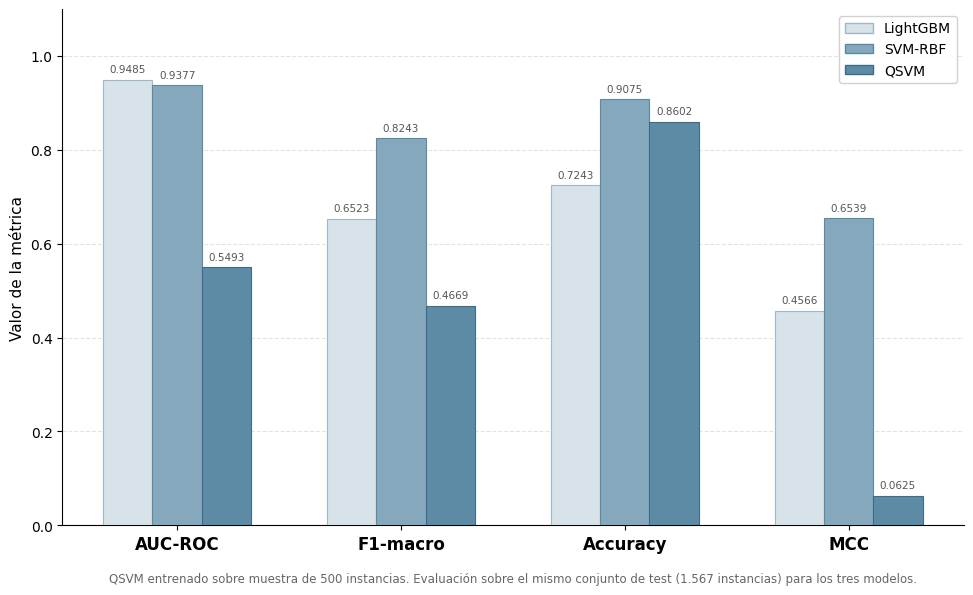

Figura guardada: /Volumes/workspace/default/nhanes/models/comparativa_metricas_por_metrica.png


In [0]:
try:
    models_dir
except NameError:
    models_dir = "/Volumes/workspace/default/nhanes/models"

os.makedirs(models_dir, exist_ok=True)

metricas = ['AUC-ROC', 'F1-macro', 'Accuracy', 'MCC']
modelos  = ['LightGBM', 'SVM-RBF', 'QSVM']

valores = {
    'LightGBM': [0.9485, 0.6523, 0.7243, 0.4566],
    'SVM-RBF':  [0.9377, 0.8243, 0.9075, 0.6539],
    'QSVM':     [0.5493, 0.4669, 0.8602, 0.0625],
}

# Escala gradual — un tono por modelo
colores = ['#D7E2E9', '#86A8BC', '#5D8BA6']
bordes  = ['#A0B8C5', '#5A8AA3', '#3D6C87']

x     = np.arange(len(metricas))
width = 0.22
n     = len(modelos)
offs  = np.linspace(-(n-1)/2, (n-1)/2, n) * width

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for i, (mod, col, brd, off) in enumerate(zip(modelos, colores, bordes, offs)):
    vals = valores[mod]
    bars = ax.bar(x + off, vals, width,
                  label=mod,
                  color=col,
                  edgecolor=brd,
                  linewidth=0.8,
                  zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.012,
                f'{v:.4f}',
                ha='center', va='bottom',
                fontsize=7.5, color='#555555')

ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=12, fontweight='bold')
ax.set_ylabel('Valor de la métrica', fontsize=11)
ax.set_ylim(0, 1.10)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}'))
ax.grid(axis='y', linestyle='--', alpha=0.35, zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

leyenda = [mpatches.Patch(facecolor=c, edgecolor=b, label=m)
           for c, b, m in zip(colores, bordes, modelos)]
ax.legend(handles=leyenda, loc='upper right',
          fontsize=10, framealpha=0.9, edgecolor='#cccccc')

ax.annotate(
    'QSVM entrenado sobre muestra de 500 instancias. '
    'Evaluación sobre el mismo conjunto de test (1.567 instancias) para los tres modelos.',
    xy=(0.5, -0.11), xycoords='axes fraction',
    ha='center', fontsize=8.5, color='#666666'
)

plt.tight_layout()
fig_path = f'{models_dir}/comparativa_metricas_por_metrica.png'
plt.savefig(fig_path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Figura guardada: {fig_path}')

In [0]:
print("=== VALIDACION FINAL QSVM ===")

print("\n1. Métricas:")
df_check = pd.read_csv(f"{models_dir}/metricas_qsvm.csv")
print(df_check[["modelo","auc_roc","f1_macro","accuracy","mcc"]].to_string(index=False))

print("\n2. Artefactos generados:")
artefactos = [
    "qsvm_final.pkl",
    "metricas_qsvm.csv",
    "roc_qsvm.png",
    "confusion_qsvm.png",
    "circuito_zzfeaturemap.png",
    "circuito_qsvm_8qubits_anexo.png",
    "comparativa_metricas_por_metrica.png",
    "qsvm_y_scores.npy",
    "qsvm_y_test.npy"
]
for artefacto in artefactos:
    existe = os.path.exists(f"{models_dir}/{artefacto}")
    tam    = os.path.getsize(f"{models_dir}/{artefacto}") / 1024 if existe else 0
    estado = f"OK ({tam:.1f} KB)" if existe else "❌ FALTA"
    print(f"   {artefacto}: {estado}")

print("\n=== QSVM COMPLETADO OK ===")

=== VALIDACION FINAL QSVM ===

1. Métricas:
modelo  auc_roc  f1_macro  accuracy    mcc
  QSVM   0.5493    0.4669    0.8602 0.0625

2. Artefactos generados:
   qsvm_final.pkl: OK (77.1 KB)
   metricas_qsvm.csv: OK (0.2 KB)
   roc_qsvm.png: OK (54.5 KB)
   confusion_qsvm.png: OK (40.5 KB)
   circuito_zzfeaturemap.png: OK (56.8 KB)
   circuito_qsvm_8qubits_anexo.png: OK (119.8 KB)
   comparativa_metricas_por_metrica.png: OK (96.1 KB)
   qsvm_y_scores.npy: OK (12.4 KB)
   qsvm_y_test.npy: OK (12.4 KB)

=== QSVM COMPLETADO OK ===
